In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#data source: https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
df=pd.read_csv('car_fuel_efficiency_2026.csv')
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [12]:
#data preparation
str_cols=df.columns[df.dtypes == 'str']
for i in str_cols:
    df[i]= df[i].str.lower().str.replace(' ','_')

df.head(10)

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,europe,gasoline,front-wheel_drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,europe,diesel,front-wheel_drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,asia,gasoline,front-wheel_drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,europe,gasoline,front-wheel_drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,usa,diesel,front-wheel_drive,3,2580,7,304.0,4510,17.5,31.0
5,2007,usa,hybrid,front-wheel_drive,2,2290,6,266.0,4260,18.8,31.2
6,1992,asia,gasoline,front-wheel_drive,2,2270,6,250.0,4310,21.7,26.8
7,2005,usa,gasoline,front-wheel_drive,4,2370,6,279.0,4090,17.4,30.2
8,1997,asia,gasoline,rear-wheel_drive,3,2330,6,251.0,4230,19.5,30.9
9,2004,usa,diesel,all-wheel_drive,5,2330,6,280.0,4620,17.7,31.2


In [16]:
df_sub=df[['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']]
df_sub.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

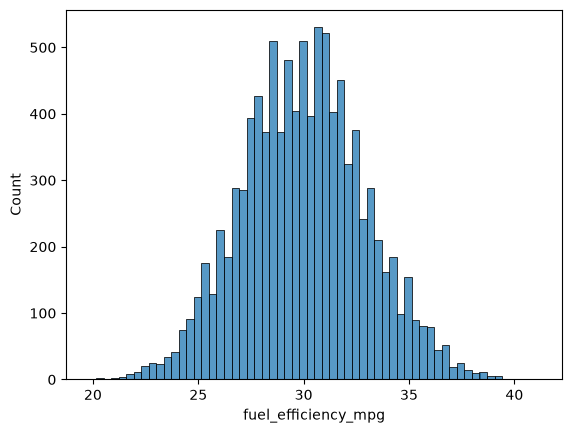

In [ ]:
sns.histplot(df_sub['fuel_efficiency_mpg'])
#it is a normal distribution! No tail

In [ ]:
#Q1
print(df_sub.isnull().sum())
df_sub.columns[df_sub.isnull().sum()>0]
#horsepower

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64


Index(['horsepower'], dtype='str')

In [ ]:
#Q2
df_sub['horsepower'].median()
df_sub['horsepower'].describe()
#254

count    9123.000000
mean      254.446016
std        22.844613
min       171.000000
25%       239.000000
50%       254.000000
75%       270.000000
max       334.000000
Name: horsepower, dtype: float64

In [68]:
n = len(df_sub)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df_sub.iloc[idx[:n_train]]
df_val = df_sub.iloc[idx[n_train:n_train + n_val]]
df_test = df_sub.iloc[idx[n_train + n_val:]]

In [69]:
df_train=df_train.reset_index(drop=True)
df_val=df_val.reset_index(drop=True)
df_test=df_test.reset_index(drop=True)

In [70]:
#value vector
y_train=df_train['fuel_efficiency_mpg'].values
y_val=df_val['fuel_efficiency_mpg'].values
y_test=df_test['fuel_efficiency_mpg'].values

In [71]:
del(df_train['fuel_efficiency_mpg'])
del(df_val['fuel_efficiency_mpg'])
del(df_test['fuel_efficiency_mpg'])

In [42]:
#Model training
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [43]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year
0,1900,239.0,3790,2015
1,2000,224.0,4380,1992
2,2330,286.0,4090,2022
3,2300,NaN,4150,1997
4,2340,269.0,4400,2001


In [60]:
features=['engine_displacement','horsepower','vehicle_weight','model_year'] #fuel_efficiency is removed as it is target variable
def prepare_X(df): #function to prepare any input df, by taking feature columns, and replacing nan entries. Adding the car age.
    df=df.copy()
    df_num=df[features]
    df_num=df_num.fillna(0)
    X=df_num.values
    return X

def prepare_X_mean(df): #replaces NaN with mean
    df=df.copy()
    df_num=df[features]
    df_num=df_num.fillna(df_train.horsepower.mean())
    X=df_num.values
    return X

In [56]:
def rmse(y,y_pred): #y=y_train or the target values
    se= (y - y_pred)**2
    mse=se.mean()
    return np.sqrt(mse)

In [72]:
#Q3
X_train=prepare_X(df_train)
w0,w= train_linear_regression(X_train, y_train)
X_val=prepare_X(df_val)
y_pred= w0 + X_val.dot(w)
score0= round(rmse(y_val,y_pred),3)

X_train=prepare_X_mean(df_train)
w0,w= train_linear_regression(X_train, y_train)
X_val=prepare_X(df_val)
y_pred= w0 + X_val.dot(w)
score_mean= round(rmse(y_val,y_pred),3)

In [73]:
#Q3
score0, score_mean
#Although replacing the NaN with zero has better results, both are comparable.

(np.float64(2.205), np.float64(2.232))

In [63]:
#Q4
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [74]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train,r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = round(rmse(y_val, y_pred),4)
    print(r, w0, score)

#r=0 gives the lowest rmse.

0 -153.8849618823138 2.2053
0.01 -148.3092124404723 2.2058
0.1 -111.83871039306318 2.2241
1 -32.331865964971264 2.3492
5 -7.7728522099734025 2.4094
10 -3.9871164160193766 2.4195
100 -0.40821964884790385 2.4292


In [75]:
#Q5
seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
scores=[]
for i in seeds:
    np.random.seed(i)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df_sub.iloc[idx[:n_train]]
    df_val = df_sub.iloc[idx[n_train:n_train + n_val]]
    df_test = df_sub.iloc[idx[n_train + n_val:]]

    df_train=df_train.reset_index(drop=True)
    df_val=df_val.reset_index(drop=True)
    df_test=df_test.reset_index(drop=True)

    y_train=df_train['fuel_efficiency_mpg'].values
    y_val=df_val['fuel_efficiency_mpg'].values
    y_test=df_test['fuel_efficiency_mpg'].values

    del(df_train['fuel_efficiency_mpg'])
    del(df_val['fuel_efficiency_mpg'])
    del(df_test['fuel_efficiency_mpg'])

    X_train=prepare_X(df_train)
    w0,w= train_linear_regression(X_train, y_train)
    X_val=prepare_X(df_val)
    y_pred= w0 + X_val.dot(w)
    score= rmse(y_val,y_pred)

    scores.append(score)

In [ ]:
#Q5
print(scores) #rmse of different seeds
std=round(np.std(scores),3)
print(std)
#0.029

[np.float64(2.239204143046126), np.float64(2.2021128210838845), np.float64(2.1634197787530947), np.float64(2.2043588768539224), np.float64(2.2018800943311554), np.float64(2.2457851509085134), np.float64(2.2697212079524043), np.float64(2.190794599933443), np.float64(2.216611201686444), np.float64(2.2070365928178957)]
0.029


In [ ]:
#Q6
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df_sub.iloc[idx[:n_train]]
df_val = df_sub.iloc[idx[n_train:n_train + n_val]]
df_test = df_sub.iloc[idx[n_train + n_val:]]

df_train=df_train.reset_index(drop=True)
df_val=df_val.reset_index(drop=True)
df_test=df_test.reset_index(drop=True)

y_train=df_train['fuel_efficiency_mpg'].values
y_val=df_val['fuel_efficiency_mpg'].values
y_test=df_test['fuel_efficiency_mpg'].values

del(df_train['fuel_efficiency_mpg'])
del(df_val['fuel_efficiency_mpg'])
del(df_test['fuel_efficiency_mpg'])

df_full_train= pd.concat([df_train, df_val])
df_full_train=df_full_train.reset_index(drop=True)
y_full_train=np.concat([y_train,y_val])

X_full_train=prepare_X(df_full_train)
w0,w= train_linear_regression_reg(X_full_train, y_full_train,r=0.001)
X_test=prepare_X(df_test)
y_pred= w0 + X_test.dot(w)
score= rmse(y_test,y_pred)
print(round(score,3))
#2.236

2.236
